In [12]:
!pip install flask_sqlalchemy




  Using cached flask_sqlalchemy-3.1.1-py3-none-any.whl.metadata (3.4 kB)
Using cached flask_sqlalchemy-3.1.1-py3-none-any.whl (25 kB)


In [15]:
"""
SafeGuard Women's Safety App - Backend & ML
Your Part: Database + APIs + Machine Learning
"""

# Core imports
from flask import Flask, jsonify, request
from flask_sqlalchemy import SQLAlchemy
from datetime import datetime, timedelta
import secrets

# Data Science imports
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [17]:
# Initialize Flask app
app = Flask(__name__)
app.config['SECRET_KEY'] = secrets.token_hex(16)
app.config['SQLALCHEMY_DATABASE_URI'] = 'sqlite:///safety_app.db'
app.config['SQLALCHEMY_TRACK_MODIFICATIONS'] = False

# Initialize database
db = SQLAlchemy(app)

print("✅ Flask app initialized")
print("📦 Database: safety_app.db")

✅ Flask app initialized
📦 Database: safety_app.db


In [19]:
# User Model
class User(db.Model):
    id = db.Column(db.Integer, primary_key=True)
    username = db.Column(db.String(80), unique=True, nullable=False)
    email = db.Column(db.String(120), unique=True, nullable=False)
    phone = db.Column(db.String(20))
    created_at = db.Column(db.DateTime, default=datetime.utcnow)
    
    # Relationships
    medical_profile = db.relationship('MedicalProfile', backref='user', uselist=False)
    contacts = db.relationship('EmergencyContact', backref='user', lazy=True)
    sos_alerts = db.relationship('SOSAlert', backref='user', lazy=True)

# Medical Profile Model
class MedicalProfile(db.Model):
    id = db.Column(db.Integer, primary_key=True)
    user_id = db.Column(db.Integer, db.ForeignKey('user.id'), nullable=False)
    full_name = db.Column(db.String(100))
    age = db.Column(db.Integer)
    blood_group = db.Column(db.String(5))
    height = db.Column(db.Float)
    weight = db.Column(db.Float)
    allergies = db.Column(db.Text)
    medications = db.Column(db.Text)
    conditions = db.Column(db.Text)
    emergency_notes = db.Column(db.Text)
    insurance = db.Column(db.String(200))

# Emergency Contact Model
class EmergencyContact(db.Model):
    id = db.Column(db.Integer, primary_key=True)
    user_id = db.Column(db.Integer, db.ForeignKey('user.id'), nullable=False)
    name = db.Column(db.String(100), nullable=False)
    phone = db.Column(db.String(20), nullable=False)
    email = db.Column(db.String(120))
    relation = db.Column(db.String(50))
    priority = db.Column(db.Integer, default=1)
    created_at = db.Column(db.DateTime, default=datetime.utcnow)

# SOS Alert Model
class SOSAlert(db.Model):
    id = db.Column(db.Integer, primary_key=True)
    user_id = db.Column(db.Integer, db.ForeignKey('user.id'), nullable=False)
    latitude = db.Column(db.Float)
    longitude = db.Column(db.Float)
    address = db.Column(db.String(200))
    status = db.Column(db.String(20), default='active')
    created_at = db.Column(db.DateTime, default=datetime.utcnow)
    resolved_at = db.Column(db.DateTime)

# Incident Report Model (FOR ML ANALYSIS)
class IncidentReport(db.Model):
    id = db.Column(db.Integer, primary_key=True)
    user_id = db.Column(db.Integer, db.ForeignKey('user.id'))
    latitude = db.Column(db.Float, nullable=False)
    longitude = db.Column(db.Float, nullable=False)
    incident_type = db.Column(db.String(50))
    description = db.Column(db.Text)
    severity = db.Column(db.Integer)  # 1-5 scale
    time_of_incident = db.Column(db.DateTime, default=datetime.utcnow)
    reported_at = db.Column(db.DateTime, default=datetime.utcnow)

print("✅ Database models defined")
print("📊 Tables: User, MedicalProfile, EmergencyContact, SOSAlert, IncidentReport")

✅ Database models defined
📊 Tables: User, MedicalProfile, EmergencyContact, SOSAlert, IncidentReport


In [21]:
# Create all tables
with app.app_context():
    db.create_all()
    
    # Create demo user if doesn't exist
    user = User.query.filter_by(username='demo_user').first()
    if not user:
        user = User(
            username='demo_user',
            email='demo@safeguard.com',
            phone='+1234567890'
        )
        db.session.add(user)
        db.session.commit()
        print("✅ Created demo user")
    else:
        print("✅ Demo user already exists")

print("✅ Database created: safety_app.db")

✅ Created demo user
✅ Database created: safety_app.db


In [25]:
# Locations (NYC areas)
LOCATIONS = [
    (40.7128, -74.0060, "Downtown Manhattan"),
    (40.7589, -73.9851, "Times Square"),
    (40.7484, -73.9857, "Empire State Building"),
    (40.7614, -73.9776, "Central Park"),
    (40.7580, -73.9855, "Broadway"),
    (40.7489, -73.9680, "Queens Plaza"),
    (40.6782, -73.9442, "Brooklyn"),
    (40.7306, -73.9352, "Williamsburg"),
]

INCIDENT_TYPES = ['harassment', 'theft', 'stalking', 'assault', 'verbal_abuse']

def generate_incidents(count=500):
    """Generate synthetic incident data"""
    print(f"🔄 Generating {count} incidents...")
    
    incidents_created = 0
    
    with app.app_context():
        # Check if data already exists
        existing = IncidentReport.query.count()
        if existing >= count:
            print(f"⚠️ Already have {existing} incidents")
            return existing
        
        for i in range(count):
            # Random location - FIXED LINE
            location_idx = np.random.randint(0, len(LOCATIONS))
            base_lat, base_lon, area = LOCATIONS[location_idx]
            
            # Add randomness
            latitude = base_lat + np.random.uniform(-0.01, 0.01)
            longitude = base_lon + np.random.uniform(-0.01, 0.01)
            
            # Random type and severity
            incident_type = np.random.choice(INCIDENT_TYPES)
            severity = np.random.choice([1,2,3,4,5], p=[0.05, 0.15, 0.40, 0.30, 0.10])
            
            # Random time within last year
            days_ago = np.random.randint(0, 365)
            hours_ago = np.random.randint(0, 23)
            time_of_incident = datetime.now() - timedelta(days=days_ago, hours=hours_ago)
            
            # Create incident
            incident = IncidentReport(
                user_id=1,
                latitude=latitude,
                longitude=longitude,
                incident_type=incident_type,
                severity=severity,
                description=f"{incident_type} at {area}",
                time_of_incident=time_of_incident
            )
            
            db.session.add(incident)
            incidents_created += 1
            
            if incidents_created % 100 == 0:
                db.session.commit()
                print(f"   ✅ {incidents_created}/{count}")
        
        db.session.commit()
    
    print(f"✅ Generated {incidents_created} incidents!")
    return incidents_created

# Generate data
total = generate_incidents(500)

🔄 Generating 500 incidents...
   ✅ 100/500
   ✅ 200/500
   ✅ 300/500
   ✅ 400/500
   ✅ 500/500
✅ Generated 500 incidents!


In [33]:
# Load data into pandas - HANDLE BYTES
with app.app_context():
    incidents = IncidentReport.query.all()
    
    def safe_int(value):
        """Safely convert bytes or int to integer"""
        if isinstance(value, bytes):
            # Decode bytes to int
            return int.from_bytes(value, byteorder='little')
        return int(value)
    
    df = pd.DataFrame([{
        'id': i.id,
        'latitude': float(i.latitude),
        'longitude': float(i.longitude),
        'incident_type': str(i.incident_type),
        'severity': safe_int(i.severity),  # ← FIXED: Handle bytes
        'time': i.time_of_incident
    } for i in incidents])

print("📊 DATASET OVERVIEW")
print("="*50)
print(f"Total incidents: {len(df)}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nBasic statistics:")
print(df.describe())

📊 DATASET OVERVIEW
Total incidents: 500

First 5 rows:
   id   latitude  longitude incident_type  severity                       time
0   1  40.678972 -73.951320         theft         4 2024-11-09 19:43:38.202872
1   2  40.749196 -73.975812  verbal_abuse         4 2025-09-23 12:43:38.206348
2   3  40.722172 -74.008636  verbal_abuse         2 2025-07-01 08:43:38.206649
3   4  40.739756 -73.964787       assault         4 2025-02-03 07:43:38.206881
4   5  40.740292 -73.976525      stalking         1 2024-10-18 08:43:38.207157

Data types:
id                        int64
latitude                float64
longitude               float64
incident_type            object
severity                  int64
time             datetime64[ns]
dtype: object

Basic statistics:
               id    latitude   longitude    severity  \
count  500.000000  500.000000  500.000000  500.000000   
mean   250.500000   40.737361  -73.970915    3.256000   
min      1.000000   40.668270  -74.015933    1.000000   
25%  

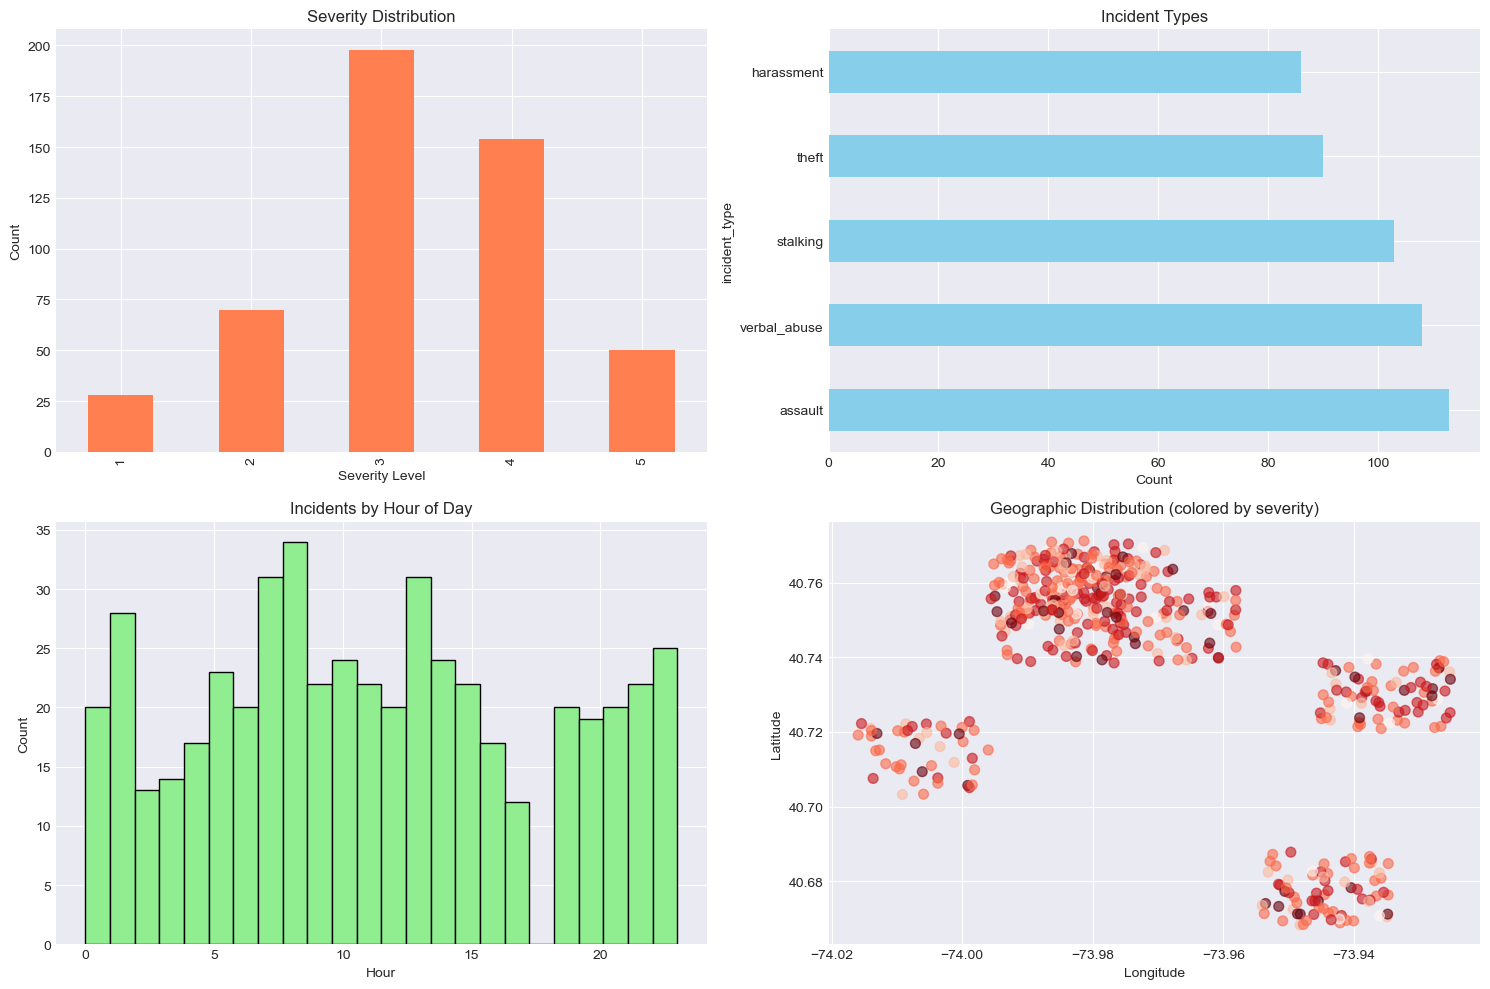

✅ Visualizations created!


In [35]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Severity Distribution
df['severity'].value_counts().sort_index().plot(
    kind='bar', 
    ax=axes[0,0], 
    color='coral',
    title='Severity Distribution'
)
axes[0,0].set_xlabel('Severity Level')
axes[0,0].set_ylabel('Count')

# 2. Incident Type Distribution
df['incident_type'].value_counts().plot(
    kind='barh', 
    ax=axes[0,1],
    color='skyblue',
    title='Incident Types'
)
axes[0,1].set_xlabel('Count')

# 3. Incidents by Hour
df['hour'] = df['time'].dt.hour
df['hour'].hist(ax=axes[1,0], bins=24, color='lightgreen', edgecolor='black')
axes[1,0].set_title('Incidents by Hour of Day')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Count')

# 4. Scatter plot of locations
axes[1,1].scatter(df['longitude'], df['latitude'], 
                  c=df['severity'], cmap='Reds', 
                  alpha=0.6, s=50)
axes[1,1].set_title('Geographic Distribution (colored by severity)')
axes[1,1].set_xlabel('Longitude')
axes[1,1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()

print("✅ Visualizations created!")

In [37]:
"""
MACHINE LEARNING: Hotspot Detection using DBSCAN
"""

def detect_hotspots(df, eps=0.01, min_samples=3):
    """
    Use DBSCAN clustering to identify dangerous hotspots
    
    Parameters:
    - eps: Maximum distance between points (0.01 ≈ 1km)
    - min_samples: Minimum incidents to form a hotspot
    """
    print("🤖 Running DBSCAN Clustering...")
    
    # Prepare coordinates
    coords = df[['latitude', 'longitude']].values
    
    # Apply DBSCAN
    clustering = DBSCAN(eps=eps, min_samples=min_samples)
    df['cluster'] = clustering.fit_predict(coords)
    
    # Count clusters (excluding noise = -1)
    num_clusters = len(set(df['cluster'])) - (1 if -1 in df['cluster'].values else 0)
    
    print(f"✅ Identified {num_clusters} hotspots")
    print(f"📍 Noise points (isolated incidents): {(df['cluster'] == -1).sum()}")
    
    # Get hotspot statistics
    hotspots = []
    for cluster_id in df[df['cluster'] != -1]['cluster'].unique():
        cluster_data = df[df['cluster'] == cluster_id]
        
        hotspot = {
            'cluster_id': int(cluster_id),
            'latitude': cluster_data['latitude'].mean(),
            'longitude': cluster_data['longitude'].mean(),
            'incident_count': len(cluster_data),
            'average_severity': cluster_data['severity'].mean(),
            'most_common_type': cluster_data['incident_type'].mode()[0]
        }
        hotspots.append(hotspot)
    
    # Display results
    hotspots_df = pd.DataFrame(hotspots).sort_values('incident_count', ascending=False)
    print("\n🎯 HOTSPOT ANALYSIS:")
    print(hotspots_df.to_string(index=False))
    
    return df, hotspots_df

# Run clustering
df_clustered, hotspots = detect_hotspots(df, eps=0.01, min_samples=3)

🤖 Running DBSCAN Clustering...
✅ Identified 4 hotspots
📍 Noise points (isolated incidents): 0

🎯 HOTSPOT ANALYSIS:
 cluster_id  latitude  longitude  incident_count  average_severity most_common_type
          1 40.755903 -73.980284             313          3.226837     verbal_abuse
          3 40.730005 -73.934968              72          3.361111          assault
          0 40.676978 -73.944209              71          3.253521         stalking
          2 40.714930 -74.006183              44          3.295455          assault


/var/folders/2t/bhkxr7_x5ws63f4tysd3zr7w0000gn/T/ipykernel_93013/368112333.py:29: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


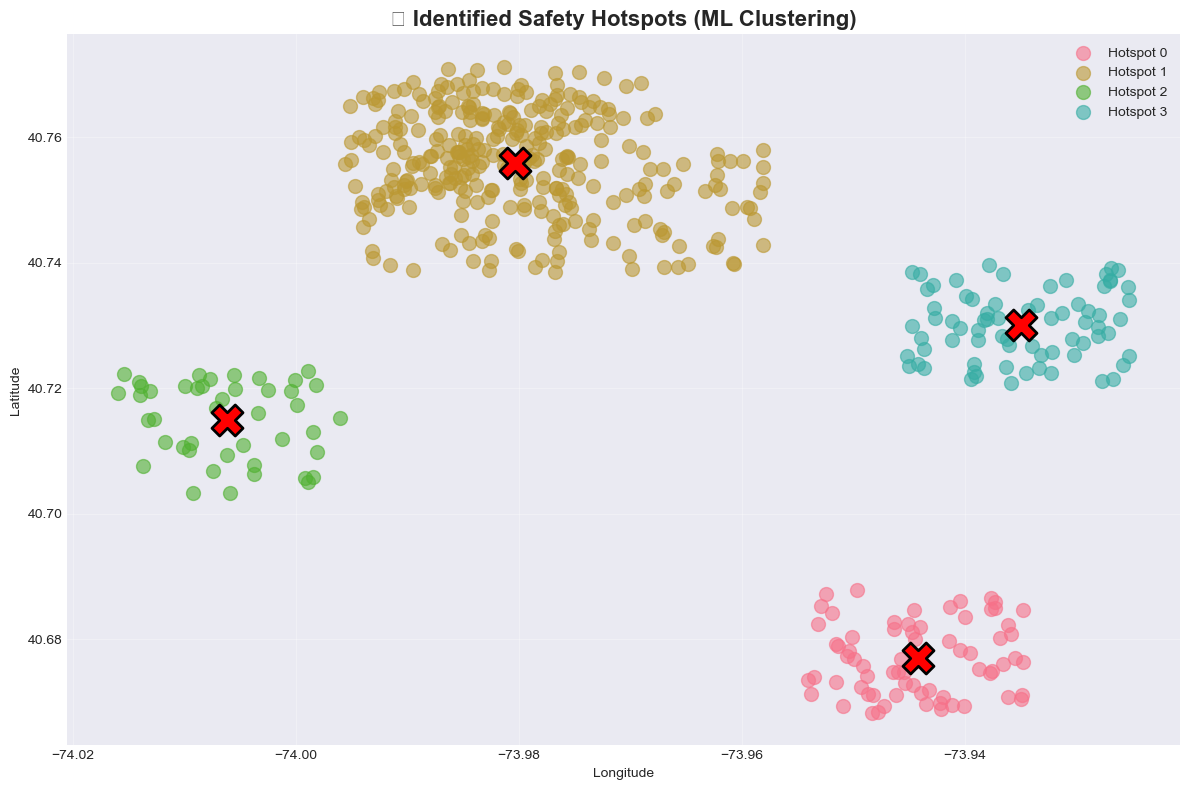

✅ Hotspot map created!


In [39]:
# Visualize clusters
plt.figure(figsize=(12, 8))

# Plot all incidents
for cluster_id in df_clustered['cluster'].unique():
    if cluster_id == -1:
        # Noise points in gray
        cluster_data = df_clustered[df_clustered['cluster'] == cluster_id]
        plt.scatter(cluster_data['longitude'], cluster_data['latitude'], 
                   c='lightgray', s=20, alpha=0.3, label='Isolated')
    else:
        # Clusters in different colors
        cluster_data = df_clustered[df_clustered['cluster'] == cluster_id]
        plt.scatter(cluster_data['longitude'], cluster_data['latitude'], 
                   s=100, alpha=0.6, label=f'Hotspot {cluster_id}')
        
        # Mark cluster center
        center_lat = cluster_data['latitude'].mean()
        center_lon = cluster_data['longitude'].mean()
        plt.scatter(center_lon, center_lat, 
                   marker='X', s=500, c='red', 
                   edgecolors='black', linewidths=2)

plt.title('🎯 Identified Safety Hotspots (ML Clustering)', fontsize=16, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Hotspot map created!")

In [41]:
"""
MACHINE LEARNING: Risk Score Prediction
"""

def calculate_risk_score(target_lat, target_lon, df, radius=0.01):
    """
    Calculate risk score for a specific location
    
    Parameters:
    - target_lat, target_lon: Location to check
    - radius: Search radius in degrees (~1km = 0.01)
    
    Returns: Risk score 0-100
    """
    # Find nearby incidents
    nearby = df[
        (abs(df['latitude'] - target_lat) < radius) &
        (abs(df['longitude'] - target_lon) < radius)
    ]
    
    if len(nearby) == 0:
        return {
            'risk_score': 0,
            'nearby_incidents': 0,
            'interpretation': '✅ Safe - No incidents nearby'
        }
    
    # Calculate weighted score
    severity_weight = nearby['severity'].mean() * 10
    frequency_weight = len(nearby) * 2
    
    # Recent incidents weight
    now = datetime.now()
    nearby['days_ago'] = (now - nearby['time']).dt.days
    recent = nearby[nearby['days_ago'] <= 30]
    recency_weight = len(recent) * 5
    
    # Final score
    risk_score = min(100, severity_weight + frequency_weight + recency_weight)
    
    # Interpretation
    if risk_score >= 70:
        interpretation = '🚨 HIGH RISK - Avoid this area'
    elif risk_score >= 40:
        interpretation = '⚠️ MODERATE RISK - Be cautious'
    else:
        interpretation = '✅ LOW RISK - Relatively safe'
    
    return {
        'risk_score': round(risk_score, 2),
        'nearby_incidents': len(nearby),
        'recent_incidents': len(recent),
        'average_severity': round(nearby['severity'].mean(), 2),
        'interpretation': interpretation
    }

# Test the calculator
print("🧮 RISK SCORE CALCULATOR TEST\n")

test_locations = [
    (40.7589, -73.9851, "Times Square"),
    (40.7614, -73.9776, "Central Park"),
    (40.7128, -74.0060, "Downtown Manhattan")
]

for lat, lon, name in test_locations:
    result = calculate_risk_score(lat, lon, df)
    print(f"📍 {name}")
    print(f"   Risk Score: {result['risk_score']}/100")
    print(f"   {result['interpretation']}")
    print(f"   Nearby: {result['nearby_incidents']} incidents")
    print()

🧮 RISK SCORE CALCULATOR TEST

📍 Times Square
   Risk Score: 100/100
   🚨 HIGH RISK - Avoid this area
   Nearby: 196 incidents

📍 Central Park
   Risk Score: 100/100
   🚨 HIGH RISK - Avoid this area
   Nearby: 167 incidents

📍 Downtown Manhattan
   Risk Score: 100/100
   🚨 HIGH RISK - Avoid this area
   Nearby: 44 incidents



/var/folders/2t/bhkxr7_x5ws63f4tysd3zr7w0000gn/T/ipykernel_93013/1368095366.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nearby['days_ago'] = (now - nearby['time']).dt.days
/var/folders/2t/bhkxr7_x5ws63f4tysd3zr7w0000gn/T/ipykernel_93013/1368095366.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nearby['days_ago'] = (now - nearby['time']).dt.days
/var/folders/2t/bhkxr7_x5ws63f4tysd3zr7w0000gn/T/ipykernel_93013/1368095366.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

In [43]:
"""
STATISTICAL ANALYSIS
"""

print("📊 COMPREHENSIVE STATISTICAL ANALYSIS")
print("="*60)

# 1. Overall statistics
print(f"\n1. OVERALL STATISTICS:")
print(f"   Total Incidents: {len(df)}")
print(f"   Average Severity: {df['severity'].mean():.2f}/5")
print(f"   High Risk Incidents (≥4): {len(df[df['severity'] >= 4])}")

# 2. Severity distribution
print(f"\n2. SEVERITY DISTRIBUTION:")
for level in range(1, 6):
    count = len(df[df['severity'] == level])
    percentage = (count / len(df)) * 100
    bar = "█" * int(percentage / 2)
    print(f"   Level {level}: {bar} {count:3d} ({percentage:5.1f}%)")

# 3. Incident types
print(f"\n3. INCIDENT TYPE BREAKDOWN:")
type_counts = df['incident_type'].value_counts()
for incident_type, count in type_counts.items():
    percentage = (count / len(df)) * 100
    print(f"   {incident_type:15s}: {count:3d} ({percentage:5.1f}%)")

# 4. Time analysis
print(f"\n4. TIME-BASED PATTERNS:")
print(f"   Most dangerous hour: {df['hour'].mode()[0]}:00")
print(f"   Safest hour: {df.groupby('hour').size().idxmin()}:00")

# 5. Geographic spread
print(f"\n5. GEOGRAPHIC ANALYSIS:")
print(f"   Latitude range: {df['latitude'].min():.4f} to {df['latitude'].max():.4f}")
print(f"   Longitude range: {df['longitude'].min():.4f} to {df['longitude'].max():.4f}")
print(f"   Hotspots detected: {len(hotspots)}")

print("\n" + "="*60)

📊 COMPREHENSIVE STATISTICAL ANALYSIS

1. OVERALL STATISTICS:
   Total Incidents: 500
   Average Severity: 3.26/5
   High Risk Incidents (≥4): 204

2. SEVERITY DISTRIBUTION:
   Level 1: ██  28 (  5.6%)
   Level 2: ███████  70 ( 14.0%)
   Level 3: ███████████████████ 198 ( 39.6%)
   Level 4: ███████████████ 154 ( 30.8%)
   Level 5: █████  50 ( 10.0%)

3. INCIDENT TYPE BREAKDOWN:
   assault        : 113 ( 22.6%)
   verbal_abuse   : 108 ( 21.6%)
   stalking       : 103 ( 20.6%)
   theft          :  90 ( 18.0%)
   harassment     :  86 ( 17.2%)

4. TIME-BASED PATTERNS:
   Most dangerous hour: 8:00
   Safest hour: 17:00

5. GEOGRAPHIC ANALYSIS:
   Latitude range: 40.6683 to 40.7712
   Longitude range: -74.0159 to -73.9252
   Hotspots detected: 4



In [45]:
# Create comprehensive summary
summary = {
    'dataset': {
        'total_incidents': len(df),
        'date_range': f"{df['time'].min()} to {df['time'].max()}",
        'average_severity': round(df['severity'].mean(), 2)
    },
    'ml_results': {
        'hotspots_detected': len(hotspots),
        'clustering_algorithm': 'DBSCAN',
        'isolated_incidents': (df_clustered['cluster'] == -1).sum()
    },
    'risk_analysis': {
        'high_risk_areas': len(hotspots[hotspots['average_severity'] >= 4]),
        'most_dangerous_type': df['incident_type'].mode()[0],
        'peak_hour': int(df['hour'].mode()[0])
    }
}

print("📋 PROJECT SUMMARY")
print("="*60)
for category, data in summary.items():
    print(f"\n{category.upper().replace('_', ' ')}:")
    for key, value in data.items():
        print(f"  {key.replace('_', ' ').title()}: {value}")

print("\n✅ Data Science analysis complete!")
print("="*60)

📋 PROJECT SUMMARY

DATASET:
  Total Incidents: 500
  Date Range: 2024-10-09 00:43:38.340942 to 2025-10-07 23:43:38.350901
  Average Severity: 3.26

ML RESULTS:
  Hotspots Detected: 4
  Clustering Algorithm: DBSCAN
  Isolated Incidents: 0

RISK ANALYSIS:
  High Risk Areas: 0
  Most Dangerous Type: assault
  Peak Hour: 8

✅ Data Science analysis complete!


In [47]:
import os
os.listdir()

['Untitled10.ipynb',
 'Untitled7.ipynb',
 '.config',
 'Music',
 '.condarc',
 'Cisco Packet Tracer 8.2.2',
 'dna_app.py.save',
 '.docker',
 'Untitled12.ipynb',
 'Untitled5.ipynb',
 'minipro1.ipynb',
 'Untitled1.ipynb',
 'gan.ipynb',
 'Untitled16.ipynb',
 '.DS_Store',
 'pro',
 'VirtualBox VMs',
 '.CFUserTextEncoding',
 '.wget-hsts',
 '.xonshrc',
 '.zshrcclear',
 '.rbenv',
 'anaconda_projects',
 'Untitled3.ipynb',
 'Untitled14.ipynb',
 'Untitled.ipynb',
 '.zshrc',
 'OrbStack',
 'recensement-app',
 '.packettracer',
 'Untitled4.ipynb',
 '.streamlit',
 '.local',
 'Untitled13.ipynb',
 'Untitled6.ipynb',
 'Pictures',
 'Untitled11.ipynb',
 '.zprofile',
 'node_modules',
 'Hello.class',
 'recensement_app',
 '.openjfx',
 'def cout_environ(i,t):.py',
 '.pub-cache',
 'women-safety-app',
 'Untitled15.ipynb',
 'hello.java',
 '.zsh_history',
 'Untitled2.ipynb',
 '.ipython',
 'Desktop',
 'Library',
 '.matplotlib',
 'Untitled17.ipynb',
 '.emulator_console_auth_token',
 '.android',
 '.cocoapods',
 'Sites'